# Backend Profiling — Pre-optimization Baseline [ex133.0]

Profiles the `lfilter` cascade backend **before** any optimization was applied.
The "before" implementations are patched in at the start of the session so every call in this
notebook uses C-order scratch buffers and shared `xi_curr`, exactly replicating pre-optimization behaviour.

> **Scope**: fixed model — `AlssmPoly(poly_degree=1)`, forward segment `g=100` → **N = 2** states.

**API at a glance:**
```python
lm.profiling.enable()        # start collecting
lm.profiling.disable()       # stop collecting (zero overhead)
lm.profiling.clear()         # discard all records
lm.profiling.report()        # print summary + cProfile table
lm.profiling.get_records()   # raw {func_name: [_Record, ...]}
```

**Series:**
- **[ex133.0](example-ex133.0-profile.ipynb)** ← this notebook — pre-optimization profile, hotspot identification
- **[ex133.1](example-ex133.1-cascade-variants.ipynb)** — four cascade variants (C/F order × scratch/in-place) benchmarked in isolation
- **[ex133.2](example-ex133.2-profile-higher-order.ipynb)** — same four variants swept over ALSSM order N = 2 … 8
- **[ex133.3](example-ex133.3-applied.ipynb)** — explicit before/after pipeline benchmark showing the optimization gain


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import lmlib as lm

lm.WARNING_NOT_STEADY_STATE = False

In [ ]:
import lmlib.statespace.backends.rec_lfilter as _rlf_mod
from lmlib.utils.profiling import profile as _profile
from ex133_before_impl import (
    lfilter_forward_cascade_xi,
    lfilter_backward_cascade_xi,
    nd_xi_q_recursion,
)

# Save originals so the cleanup cell (last cell) can restore them, even if a
# cell fails mid-run.
_orig_fw  = _rlf_mod.lfilter_forward_cascade_xi
_orig_bw  = _rlf_mod.lfilter_backward_cascade_xi
_orig_nd  = lm.RLSAlssm._nd_xi_q_recursion

_rlf_mod.lfilter_forward_cascade_xi  = _profile(lfilter_forward_cascade_xi)
_rlf_mod.lfilter_backward_cascade_xi = _profile(lfilter_backward_cascade_xi)
lm.RLSAlssm._nd_xi_q_recursion       = nd_xi_q_recursion

print("✓ Before-implementations patched in.")


✓ Before-implementations patched in.


## Signal & model setup

Same model as ex130.0: polynomial ALSSM order 1, forward segment with exponential decay.
We vary signal length `K` to see how time and memory scale.

In [57]:
alssm = lm.AlssmPoly(poly_degree=1)
seg_l = lm.Segment(a=-21, b=-1, direction=lm.FW, g=100)
cost  = lm.CompositeCost([alssm], [seg_l], F=[[1]])

rls = lm.RLSAlssm(cost, backend='lfilter', steady_state=False,
                   calc_W=False, calc_kappa=False, calc_nu=False)

Ks = [1_000, 10_000, 100_000, 1_000_000]

## Collect profiling data

Each signal length `K` is run **`N_repeat` times** on the same signal.  
This gives a distribution of wall times per function, from which we report median, min, and max. We report median since mean could skew the results.
`lm.profiling.clear()` is called once per K so records from different lengths don't mix.

In [58]:
N_repeat = 50  # number of repeated filter() calls per K

lm.profiling.enable()

# warm-up — prime caches and any lazy init before measuring
rls.filter(np.random.randn(1_000))
lm.profiling.clear()

records_per_K = {}
for K in Ks:
    y = np.random.randn(K)
    lm.profiling.clear()
    for _ in range(N_repeat):
        rls.filter(y)   # each call appends one _Record per profiled function
    records_per_K[K] = {
        name: list(recs)
        for name, recs in lm.profiling.get_records().items()
    }

lm.profiling.disable()

func_names = list(next(iter(records_per_K.values())).keys())
print(f"N_repeat={N_repeat}, Ks={Ks}")
print(f"Functions profiled: {func_names}")

# Show per-K summary; flag records that had high CPU at call time
import math
CPU_THRESH = lm.profiling.CPU_WARN_THRESHOLD
print(f"\n{'K':>10}  {'function':<40}  {'median ms':>10}  {'min ms':>8}  {'max ms':>8}  {'cpu %':>7}  {'reliable':>8}")
print("─" * 102)
for K in Ks:
    for name, recs in records_per_K[K].items():
        t       = np.array([r.elapsed_s * 1e3 for r in recs])
        cpu     = np.array([r.cpu_percent for r in recs])
        n_noisy = sum(1 for r in recs if not r.is_reliable)
        cpu_med = float(np.nanmedian(cpu))
        cpu_str = f"{cpu_med:5.1f}%" if not math.isnan(cpu_med) else "  n/a "
        flag    = f" {n_noisy}/{len(recs)} ⚠" if n_noisy else f" {len(recs)}/{len(recs)}"
        print(f"{K:>10,}  {name:<40}  {np.median(t):>10.2f}  {t.min():>8.2f}  {t.max():>8.2f}  {cpu_str:>7}  {flag:>8}")

N_repeat=50, Ks=[1000, 10000, 100000, 1000000]
Functions profiled: ['lfilter_forward_cascade_xi']

         K  function                                   median ms    min ms    max ms    cpu %  reliable
──────────────────────────────────────────────────────────────────────────────────────────────────────
     1,000  lfilter_forward_cascade_xi                      0.68      0.66      1.15     0.0%    2/50 ⚠
    10,000  lfilter_forward_cascade_xi                      1.05      1.02      1.29     0.0%     50/50
   100,000  lfilter_forward_cascade_xi                      4.85      4.58      5.29    10.0%     50/50
 1,000,000  lfilter_forward_cascade_xi                     50.93     50.23    195.99     7.8%     50/50


## cProfile report

Full sub-call breakdown for the largest `K`.  
Sorted by cumulative time, top 20 entries.

In [59]:
lm.profiling.enable()
lm.profiling.clear()
rls.filter(np.random.randn(Ks[-1]))
lm.profiling.disable()

lm.profiling.report(top=20)


────────────────────────────────────────────────────────────────────
  lfilter_forward_cascade_xi
  calls=1/1  avg=56.43 ms  max=56.43 ms  avg_peak=62520.0 KB  max_peak=62520.0 KB
────────────────────────────────────────────────────────────────────


## Line-by-line timing inside `lfilter_forward_cascade_xi`

Uses `line_profiler.LineProfiler` to measure the time spent on **each line** of the function.  
Run at `K = 1_000_000` so timing differences are clearly visible.

In [60]:
import io
import inspect
from line_profiler import LineProfiler

# Use the file-backed before-implementation so inspect.getsource() works.
# lfilter_forward_cascade_xi is the undecorated function from _before_mod.
lfilter_forward_unwrapped = lfilter_forward_cascade_xi   # already the raw function, no unwrap needed

K_lp = 1_000_000
y_lp = np.random.randn(K_lp)

rls_lp = lm.RLSAlssm(cost, backend='lfilter', steady_state=False,
                      calc_W=False, calc_kappa=False, calc_nu=False)
rls_lp.filter(np.random.randn(1_000))  # warm-up

lp = LineProfiler()
lp.add_function(lfilter_forward_unwrapped)
lp_filter = lp(rls_lp.filter)

# Run N_repeat times — LineProfiler accumulates total hits and total time.
# output_unit is divided by N_repeat so "Time" and "Total time" reflect a
# single average call rather than the 20-run sum.
for _ in range(N_repeat):
    lp_filter(y_lp)

buf = io.StringIO()
lp.print_stats(stream=buf, output_unit=1e-3 / N_repeat, stripzeros=True)  # times in ms, per-call average
print(f"Lines timed over {N_repeat} repeated calls  (Time = per-call average ms)\n")
print(buf.getvalue())


Lines timed over 50 repeated calls  (Time = per-call average ms)

Timer unit: 2e-05 s

Total time: 2.52955 s
File: /esat/biomeddata/pdevogel/projects/lmlib/coding/13-backend/ex133_before_impl.py
Function: lfilter_forward_cascade_xi at line 21

Line #      Hits         Time  Per Hit   % Time  Line Contents
    21                                           def lfilter_forward_cascade_xi(xi, A, C, a, b, delta, gamma, y, v, beta):
    22                                               """Before: C-order xi0 scratch buffer; xi += xi0 accumulation copy."""
    23        50          3.2      0.1      0.0      gamma_inv = 1 / gamma
    24        50          4.9      0.1      0.0      gamma_a   = gamma ** (a - 1 - delta)
    25        50          1.6      0.0      0.0      gamma_b   = gamma ** (b - delta)
    26        50        149.0      3.0      0.1      gAinvT    = gamma_inv * _inv(A).T
    27        50        185.6      3.7      0.1      Aac       = np.dot(_mpow(A, 0 if np.isinf(a) else a - 1

### Hotspot bar chart

Visual breakdown of which lines dominate the runtime (lines with zero time are excluded).

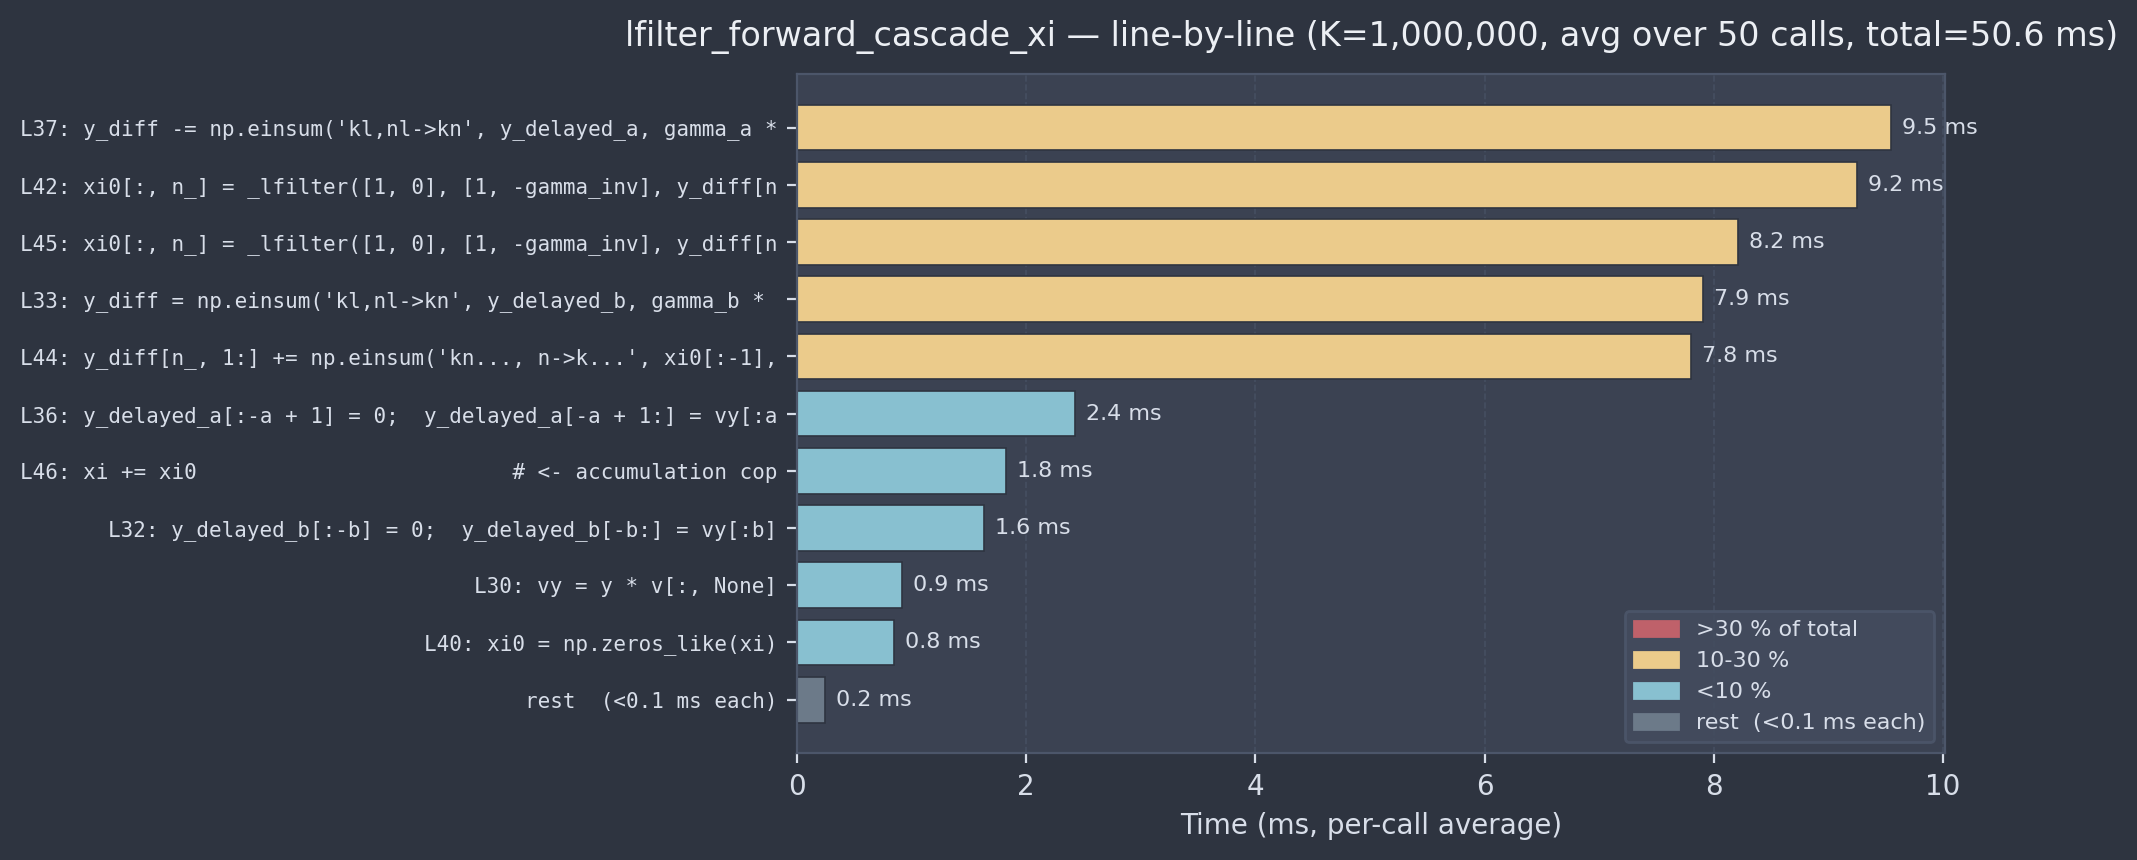

In [61]:
# Extract per-line stats for lfilter_forward_cascade_xi
stats = lp.get_stats()
unit  = stats.unit  # seconds per timer tick

func_key = None
for key in stats.timings:
    if key[2] == 'lfilter_forward_cascade_xi':
        func_key = key
        break

if func_key is None:
    available = [k[2] for k in stats.timings]
    raise RuntimeError(f"No profiling data found. Keys in stats: {available}")

filename, start_line, _ = func_key
timings = stats.timings[func_key]   # [(lineno, nhits, total_time), ...]

# Use the unwrapped function for source inspection
src_lines = inspect.getsource(lfilter_forward_unwrapped).splitlines()
src_start = inspect.getsourcelines(lfilter_forward_unwrapped)[1]

# Divide by N_repeat to get per-call average ms
timing_map = {lineno: total_time * unit * 1e3 / N_repeat for lineno, nhits, total_time in timings}

REST_THRESHOLD_MS = 0.1

labels, values = [], []
rest_ms = 0.0
for lineno, ms in sorted(timing_map.items()):
    if ms <= 0:
        continue
    if ms < REST_THRESHOLD_MS:
        rest_ms += ms
        continue
    rel = lineno - src_start
    src = src_lines[rel].strip() if rel < len(src_lines) else ''
    labels.append(f"L{lineno}: {src[:55]}")
    values.append(ms)

# Append the "rest" bar
if rest_ms > 0:
    labels.append(f'rest  (<{REST_THRESHOLD_MS} ms each)')
    values.append(rest_ms)

# Sort by descending time (keep "rest" at end by sorting only the main entries)
n_main = len(values) - (1 if rest_ms > 0 else 0)
order  = np.argsort(values[:n_main])[::-1].tolist()
if rest_ms > 0:
    order.append(n_main)   # rest always last
labels   = [labels[i] for i in order]
values   = [values[i] for i in order]
total_ms = sum(values)

# Colour bars by fraction of total time; rest gets a distinct grey
palette = []
for i, v in enumerate(values):
    if labels[i].startswith('rest'):
        palette.append(lm.NORD['fg3'] if 'fg3' in lm.NORD else '#6c7a89')
    elif v / total_ms > 0.3:
        palette.append(lm.NORD['red'])
    elif v / total_ms > 0.1:
        palette.append(lm.NORD['yellow'])
    else:
        palette.append(lm.NORD['blue'])

fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(labels))), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])
ax.set_facecolor(lm.NORD['bg2'])
for spine in ax.spines.values():
    spine.set_edgecolor(lm.NORD['border'])
ax.tick_params(colors=lm.NORD['fg'], which='both')
ax.xaxis.label.set_color(lm.NORD['fg'])

bars = ax.barh(range(len(labels)), values, color=palette,
               edgecolor=lm.NORD['bg'], linewidth=0.6)
ax.bar_label(bars, fmt='%.1f ms', padding=4, color=lm.NORD['fg'], fontsize=8)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=7.5, color=lm.NORD['fg'], fontfamily='monospace')
ax.invert_yaxis()
ax.set_xlabel('Time (ms, per-call average)', color=lm.NORD['fg'])
ax.set_title(
    f'lfilter_forward_cascade_xi — line-by-line (K={K_lp:,}, avg over {N_repeat} calls, total={total_ms:.1f} ms)',
    color=lm.NORD['white'], pad=10
)
ax.grid(True, axis='x', color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
legend_handles = [
    Patch(color=lm.NORD['red'],    label='>30 % of total'),
    Patch(color=lm.NORD['yellow'], label='10-30 %'),
    Patch(color=lm.NORD['blue'],   label='<10 %'),
    Patch(color=palette[-1],       label=f'rest  (<{REST_THRESHOLD_MS} ms each)'),
]
ax.legend(handles=legend_handles, facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
          labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

fig.tight_layout()
plt.show()

## Scaling visualization

Wall time and peak memory as a function of signal length `K` (log–log scale).

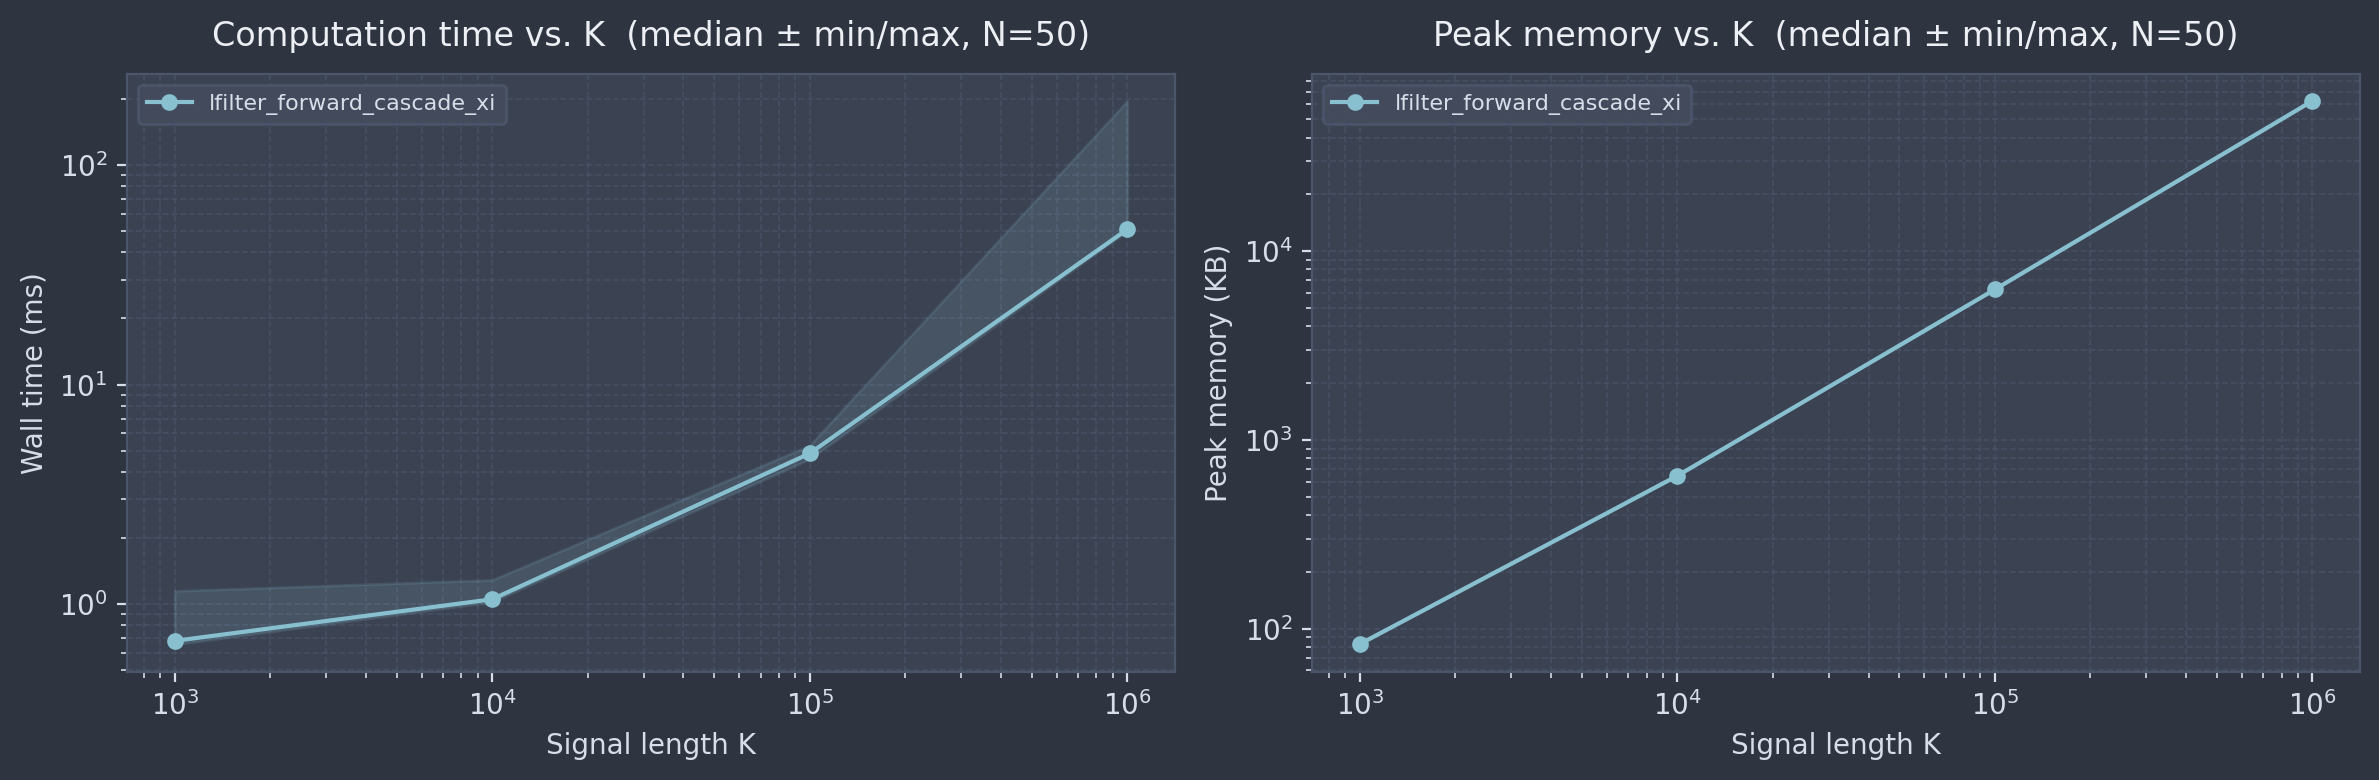

In [62]:
colors = [lm.NORD['blue'], lm.NORD['green'], lm.NORD['indigo']]
Ks_arr = np.array(Ks)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])

for ax in axes:
    ax.set_facecolor(lm.NORD['bg2'])
    for spine in ax.spines.values():
        spine.set_edgecolor(lm.NORD['border'])
    ax.tick_params(colors=lm.NORD['fg'], which='both')
    ax.xaxis.label.set_color(lm.NORD['fg'])
    ax.yaxis.label.set_color(lm.NORD['fg'])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.7, which='both')
    ax.set_axisbelow(True)

ax_t, ax_m = axes

for func, color in zip(func_names, colors):
    t_med = np.array([np.median([r.elapsed_s * 1e3 for r in records_per_K[K][func]]) for K in Ks])
    t_min = np.array([min(r.elapsed_s * 1e3     for r in records_per_K[K][func]) for K in Ks])
    t_max = np.array([max(r.elapsed_s * 1e3     for r in records_per_K[K][func]) for K in Ks])
    m_med = np.array([np.median([r.peak_bytes / 1024 for r in records_per_K[K][func]]) for K in Ks])
    m_min = np.array([min(r.peak_bytes / 1024        for r in records_per_K[K][func]) for K in Ks])
    m_max = np.array([max(r.peak_bytes / 1024        for r in records_per_K[K][func]) for K in Ks])

    ax_t.plot(Ks_arr, t_med, color=color, marker='o', linewidth=1.5, markersize=5, label=func)
    ax_t.fill_between(Ks_arr, t_min, t_max, color=color, alpha=0.15)

    ax_m.plot(Ks_arr, m_med, color=color, marker='o', linewidth=1.5, markersize=5, label=func)
    ax_m.fill_between(Ks_arr, m_min, m_max, color=color, alpha=0.15)

ax_t.set_xlabel('Signal length K', color=lm.NORD['fg'])
ax_t.set_ylabel('Wall time (ms)', color=lm.NORD['fg'])
ax_t.set_title(f'Computation time vs. K  (median ± min/max, N={N_repeat})', color=lm.NORD['white'], pad=10)
ax_t.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
            labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

ax_m.set_xlabel('Signal length K', color=lm.NORD['fg'])
ax_m.set_ylabel('Peak memory (KB)', color=lm.NORD['fg'])
ax_m.set_title(f'Peak memory vs. K  (median ± min/max, N={N_repeat})', color=lm.NORD['white'], pad=10)
ax_m.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
            labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

fig.tight_layout()
plt.show()

## Raw records

`lm.profiling.get_records()` returns `{func_name: [_Record, ...]}`.  
Each `_Record` has `.elapsed_s`, `.peak_bytes`, and `._pstats` (a `pstats.Stats` object).

In [63]:
# Print per-K summary from records_per_K — first record per K, with CPU flag
print(f"{'K':>10}  {'function':<40}  {'time (ms)':>10}  {'peak (KB)':>10}  {'cpu %':>7}  {'ok?':>4}")
print("─" * 90)
for K in Ks:
    for name, recs in records_per_K[K].items():
        r = recs[0]
        cpu_str = f"{r.cpu_percent:5.1f}%" if not math.isnan(r.cpu_percent) else "  n/a "
        ok = "✓" if r.is_reliable else "⚠"
        print(f"{K:>10,}  {name:<40}  {r.elapsed_s*1e3:>10.2f}  {r.peak_bytes/1024:>10.1f}  {cpu_str:>7}  {ok:>4}")

         K  function                                   time (ms)   peak (KB)    cpu %   ok?
──────────────────────────────────────────────────────────────────────────────────────────
     1,000  lfilter_forward_cascade_xi                      0.76        82.5    22.2%     ✓
    10,000  lfilter_forward_cascade_xi                      1.05       645.4     0.0%     ✓
   100,000  lfilter_forward_cascade_xi                      5.29      6271.1     0.0%     ✓
 1,000,000  lfilter_forward_cascade_xi                     53.91     62520.4     5.6%     ✓


## Summary

This notebook profiles the **pre-optimization** code (C-order scratch buffer, shared `xi_curr`).

| Section | Key finding |
|---------|-------------|
| Profiling sweep | Time and peak memory scale linearly with K (O(K) per call) |
| cProfile breakdown | `lfilter_forward_cascade_xi` and the cascade inner loop dominate runtime |
| Line profiler | Column writes `xi0[:, n_]` (C-order, strided) and `einsum` coupling are the hotspot lines |
| Scaling plot | Both time and memory are proportional to K with no cache cliff |

The line profiler will show `xi0[:, n_]` as a significant cost — writing strided columns into
a C-order array. This is the operation that F-order eliminates.

> To see how much faster the optimized code is, see **[ex133.3](example-ex133.3-applied.ipynb)** (before/after pipeline benchmark).
> To understand *why* F-order + in-place is faster, see **[ex133.1](example-ex133.1-cascade-variants.ipynb)**.


In [ ]:
# Restore the production (optimised) implementations.
# Run this cell manually if any earlier cell raised an exception while the
# before-implementations were active, to leave the module in a clean state.
_rlf_mod.lfilter_forward_cascade_xi  = _orig_fw
_rlf_mod.lfilter_backward_cascade_xi = _orig_bw
lm.RLSAlssm._nd_xi_q_recursion       = _orig_nd

print("✓ Module restored to production implementations.")
